# Use models from the [BioImage Model Zoo](https://bioimage.io/#/models) and public ome-zarr

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BioImagingUK/Training/blob/main/bmz.ipynb)

## Learning objectives

* Read data to analyse from an object store.
* Retrieve model from BioImage Model Zoo.
* Load labels associated to the original data.
* Compare results with ground truth.

### Install dependencies if required

The cell below will install dependencies if you choose to run the notebook in [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb#recent=true). **Do not run the cell if you are not running the notebook on Google Colab**.

If using Google Colab, **do not** use the ``Runtime>Run all`` entry.

In [3]:
# Package to access and ome-zarr
%pip install zarr
# Package to access model from the BioModel image zoo
%pip install bioimageio.core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.6/247.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 27.8 MB/s eta 0:00:00


### Lazy Load the data
The method below will return a dask array without any binary data. The dimension order of the array returned is (TCZYX). Data will be loaded when requested later.

In [ ]:
ENPOINT_URL = 'https://livingobjects.ebi.ac.uk/'

In [5]:
image_id = 6001247
name = 'idr/zarr/v0.1/%s.zarr' % (image_id)

In [10]:
import dask
import dask.array as da
def load_binary_from_s3(name, resolution='0'):
    root = '%s/%s' % (name, resolution)
    return da.from_zarr(ENPOINT_URL + root)

In [11]:
image = load_binary_from_s3(name)
print(image.shape)
# Middle z-section
z = image.shape[2] // 2

(1, 2, 257, 210, 253)


## Select model from the BioImage Model Zoo

The BioImage Model Zoo models may be identified via their bioimage.io identifier, e.g. "affable-shark" or the [__DOI__](https://doi.org/) of their [__Zenodo__](https://zenodo.org/) backup. We will work with ["affable-shark"](https://bioimage.io/#/artifacts/affable-shark), a model for 2D nuclear segmentation.

In [34]:
bmz_model_id =  "affable-shark"
bmz_model_doi =  "10.5281/zenodo.5764892"

bmz_model_id = "modest-cow"
bmz_model_doi = "10.1038/s41592-019-0612-7"

Helper method to load the model.

In [27]:
import bioimageio.core
from bioimageio.core import Tensor, Sample, create_prediction_pipeline
from bioimageio.spec.utils import load_array

# Function to handle model inference
def run_model_inference(bmz_model, arr):
    # load model
    model_resource = bioimageio.core.load_description(bmz_model)

    # load model's test input image
    test_input_image = load_array(model_resource.inputs[0].test_tensor)
    print(test_input_image.dtype)
    # match test data type with the data type of the model input
    arr = arr.astype(test_input_image.dtype)

    # create input tensor
    input_tensor = Tensor.from_numpy(arr, dims=tuple(model_resource.inputs[0].axes))

    # create collection of tensors (sample)
    inp_id = model_resource.inputs[0].id
    outp_id = model_resource.outputs[0].id
    sample = Sample(members={inp_id: input_tensor}, stat={}, id="id")

    # The prediction_pipeline function is used to run a prediction with a given model
    # It applies the pre-processing, if indicated in the model rdf.yaml,
    # runs inference with the model and applies the post-processing, again if specified in the model rdf.yaml.
    prediction_pipeline = create_prediction_pipeline(model_resource)

    # Use the new prediction pipeline to run a prediction. The prediction pipeline returns a Sample object
    prediction = prediction_pipeline.predict_sample_without_blocking(sample)

    return prediction, sample, inp_id, outp_id

The model requires to have the binary data loaded.
In this case, we will analyse run the 2D-model on the first timepoint ``t = 0``, the second channel ``c = 1`` and the middle z-section.

In [17]:
# To load all the pixels
# image_data = image.compute()
# To load the selected plane
t = 0
c = 1
image_data = image[t, c, z, :, :].compute()
print(image_data.shape)

(210, 253)


## Run the model
Run the model on the selected images to maake predictions or decisions.

In [35]:
prediction, sample, inp_id, outp_id = run_model_inference(bmz_model_id, image_data[0:128, 0:128])

float32


## Explore and plot the results

We first need to convert the prediction tensor into an array.

In [36]:
import numpy as np

pred_array = np.asarray(prediction.members[outp_id].data)
print(f"prediction shape: {pred_array.shape}")


prediction shape: (1, 2, 128, 128)


### Load the labels
Load the labels from S3. Labels are stored alongside the original binary data.

In [18]:
name = 'idr/zarr/v0.1/%s.zarr/labels' % image_id
labels = load_binary_from_s3(name)

In [19]:
print(labels.shape)

(1, 1, 257, 210, 253)


Display the original image and label alongside the predictions from the model.

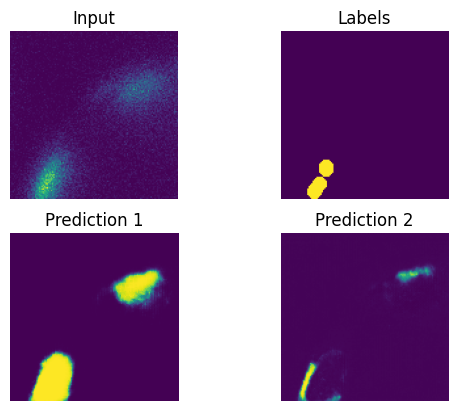

In [37]:
import matplotlib.pyplot as plt

ax1 = plt.subplot(2, 2, 1)
ax1.set_title("Input")
ax1.axis("off")
plt.imshow(image[t, c, z, 0:128, 0:128])

ax1 = plt.subplot(2, 2, 2)
ax1.set_title("Labels")
ax1.axis("off")
plt.imshow(labels[t, 0, z, 0:128, 0:128])

ax2 = plt.subplot(2, 2, 3)
ax2.set_title("Prediction 1")
ax2.axis("off")
plt.imshow(pred_array[0, 0, :, :])

ax2 = plt.subplot(2, 2, 4)
ax2.set_title("Prediction 2")
ax2.axis("off")
plt.imshow(pred_array[0, 1, :, :])

### Benchmark

We will benchmark the first output. First we need to binarise the prediction and ground truth. Note that the prediction is floating point data that shows a probability from 0 to 1.


In [38]:
# Helper method
def benchmarking_scores(pred_mask, groundtruth_mask):
    true_positives = np.sum(pred_mask*groundtruth_mask)
    true_false_postives = np.sum(pred_mask)
    precision = np.mean(true_positives/true_false_postives)
    print(f"Precision score: {round(precision, 3)}")

    total_pixel_truth = np.sum(groundtruth_mask)
    recall = np.mean(true_positives/total_pixel_truth)
    print(f"Recall score: {round(recall, 3)}")

We first binarise the prediction by selecting only pixels that are above a threshold i.e. ``0.5``. Integer data can be binarised simply by converting it to a boolean type that stores the values True and False.

In [39]:
binary_pred = pred_array[0, 0, :, :] >= 0.5
labels_array = np.asarray(labels[t, 0, z, 0:128, 0:128])
binary_gt = labels_array.astype(bool)

Run the benchmark and check the score

In [40]:
scores_image = benchmarking_scores(binary_pred, binary_gt)

Precision score: 0.205
Recall score: 1.0


Exercise:

Check with others models e.g. [serious-lobster](https://bioimage.io/#/artifacts/serious-lobster) or [modest-cow](https://bioimage.io/#/artifacts/modest-cow)

### License (BSD 2-Clause)
Copyright (C) 2026 BioImagingUK. All Rights Reserved.

Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:

Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.
Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution.
THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.